**Copyright © 2025 Raphael Senn. Licensed under the MIT License.**

**Author:** Raphael Senn (<raphaelsenn@gmx.de>)

# Generative Adversarial Networks (Goodfellow et al., 2014)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from torchvision.transforms import transforms
from torchvision.datasets import MNIST

from src.models.cgan import (
    CGANGenerator,
    CGANDiscriminator,
)

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

#### Exploring the training dataset

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # pixel transform: img.range[0, 255] -> img.range[0, 1]
    transforms.Lambda(lambda x: x.view(-1))     # shape transfrom: img.shape[1, 28, 28] -> img.shape[1, 784]
])

dataset = MNIST(root='./MNIST/', train=True, download=True, transform=transform)

#### Visualizing the Training Data

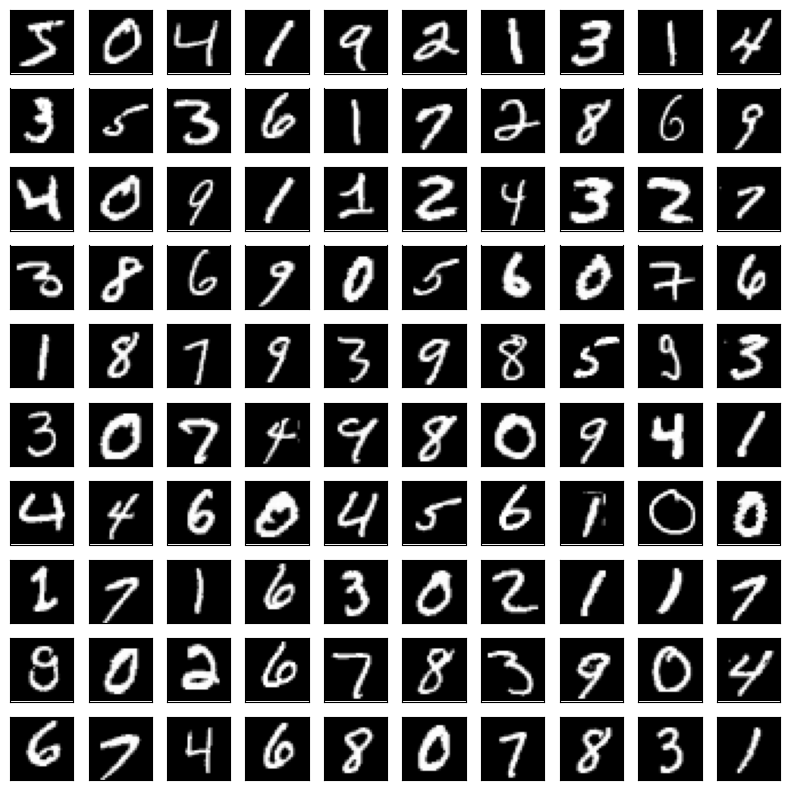

In [4]:
FIGSIZE = (8, 8)
IMAGE_SHAPE = (28, 28)
N_ROWS, N_COLS = 10, 10

_, ax = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=FIGSIZE)
ax = ax.flatten()

for i in range(N_ROWS * N_COLS):
    img, _ = dataset[i]
    img = img.reshape(IMAGE_SHAPE)
    ax[i].imshow(img, cmap='gray')
    ax[i].set_xticks([]),
    ax[i].set_yticks([])

plt.subplots_adjust(
    left=0,
    right=1,
    bottom=0,
    top=1,
    wspace=0,
    hspace=0,
)

plt.tight_layout()
plt.show()

### Visualize Training Loss

In [5]:
report = pd.read_csv("cgan-mnist/cgan-mnist_report.csv")
report.head()

,Loss_G,Loss_D
0,4.570930,0.567240
1,3.894869,0.505721
2,2.428379,0.761984
3,1.632218,0.970571
4,1.365772,1.082129


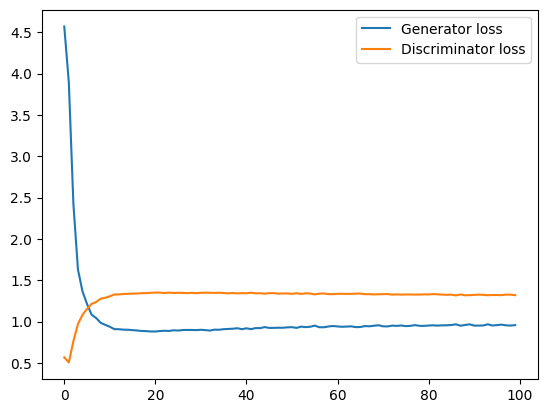

In [6]:
_, ax = plt.subplots()

ax.plot(np.arange(len(report)), report["Loss_G"], label="Generator loss")
ax.plot(np.arange(len(report)), report["Loss_D"], label="Discriminator loss")
ax.legend()
plt.show()

## Fake Data

In [ ]:
generator = CGANGenerator()
discriminator = CGANDiscriminator()

generator.load_state_dict(
    torch.load(
        "cgan-mnist/generator_cgan-mnist_ngfNone_epochs100.pth", map_location="cpu", weights_only=True
    )
)
discriminator.load_state_dict(
    torch.load(
        "cgan-mnist/discriminator_cgan-mnist_ndfNone_epochs100.pth", map_location="cpu", weights_only=True
    )
)

<All keys matched successfully>

In [8]:
generator.eval()

CGANGenerator(
  (branch_noise): Sequential(
    (0): Linear(in_features=100, out_features=200, bias=True)
    (1): ReLU(inplace=True)
  )
  (branch_classes): Sequential(
    (0): Linear(in_features=10, out_features=1000, bias=True)
    (1): ReLU(inplace=True)
  )
  (out): Sequential(
    (0): Linear(in_features=1200, out_features=1200, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=1200, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

In [9]:
num_params_g = sum(p.numel() for p in generator.parameters())
num_params_d = sum(p.numel() for p in discriminator.parameters())
print(f'Generator has: {num_params_g} learnable parameters')
print(f'Discrimintor has: {num_params_d} learnable parameters')

Generator has: 2413984 learnable parameters
Discrimintor has: 1224351 learnable parameters


#### Generating Fake Data

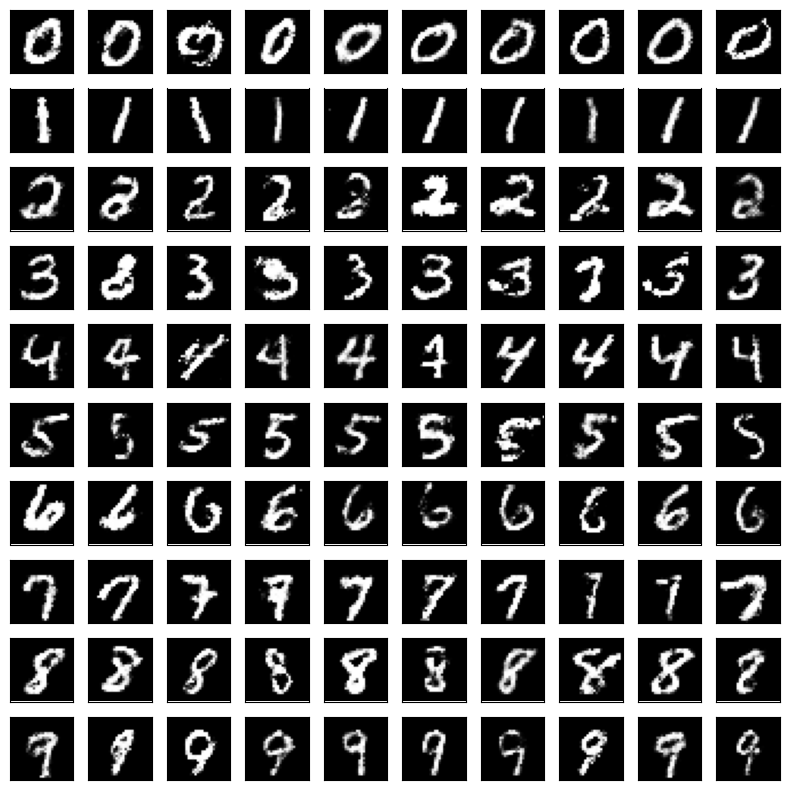

In [ ]:
Z = torch.rand(size=(N_ROWS * N_COLS, 100)) * 2 - 1
Y = torch.tensor([i for i in range(0, 10) for _ in range(0, 10)])
Y = torch.nn.functional.one_hot(Y, num_classes=10).float()
data_fake = generator(Z, Y)

_, ax = plt.subplots(nrows=N_ROWS, ncols=N_COLS, figsize=FIGSIZE)
ax = ax.flatten()

for i in range(N_ROWS * N_COLS):
    img = data_fake[i].cpu().detach().numpy().reshape(IMAGE_SHAPE)
    ax[i].imshow(img, cmap='gray')
    ax[i].set_xticks([]),
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()